In [2]:
import torch
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from scene import Scene
from tqdm import tqdm
from os import makedirs
from gaussian_renderer import render
import torchvision
from utils.general_utils import safe_state
from argparse import ArgumentParser
from arguments import ModelParams, PipelineParams, get_combined_args
from gaussian_renderer import GaussianModel
try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False

In [3]:
from argparse import Namespace
parser = ArgumentParser(description="Testing script parameters")

model = ModelParams(parser, sentinel=True)
pipeline = PipelineParams(parser)

args = Namespace(
    sh_degree = 3,
    model_path="../output/6bd50db1-7",
    source_path="../data/bigfoot",
    images = "images",
    depths = "",
    resolution = -1,
    white_background = False,
    train_test_exp = False,
    data_device = "cuda",
    eval = False,
    debug = False,
    antialiasing = False,
    convert_SHs_python = False,
    compute_cov3D_python = False
)

dataset = model.extract(args)
pipeline = pipeline.extract(args)

gaussians = GaussianModel(dataset.sh_degree)



# Sceneの作成
scene = Scene(dataset, gaussians, load_iteration=-1, shuffle=False)


Loading trained model at iteration 30000
Reading camera 1/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2582.0138469010963 for both axes.
Reading camera 2/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2595.9419245632284 for both axes.
Reading camera 3/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2609.0026778697584 for both axes.
Reading camera 4/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2626.3193412834958 for both axes.
Reading camera 5/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2620.1899792579256 for both axes.
Reading camera 6/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2612.4946906037335 for both axes.
Reading camera 7/69Warning: Colmap camera model SIMPLE_RADIAL not handled, using focal length 2613.3063885904285 for both axes.
Reading camera 8/69Warning: Colmap camera model SIMPLE_RADIAL n

3_0181.png
0.704232208709321 0.4076177113708152
87


(-0.5, 1599.5, 899.5, -0.5)

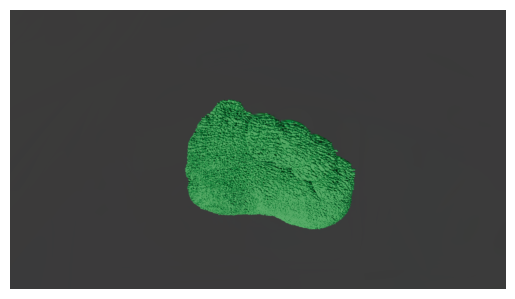

In [4]:
from pathlib import Path
ply_file = Path(r"C:\Users\Maemaeko\imari_lab\gaussian-splatting\output\6bd50db1-7\point_cloud\iteration_30000\point_cloud.ply")
scene.gaussians.load_ply(ply_file)
gaussians = scene.gaussians
import matplotlib.pyplot as plt
view = scene.getTrainCameras()[36]
print(view.image_name)
print(view.FoVx, view.FoVy)
print(view.colmap_id)
bg_color = [1,1,1] if dataset.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
rendering = render(view, gaussians, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする



3_0181.png
0.704232208709321 0.4076177113708152
87


(-0.5, 1599.5, 899.5, -0.5)

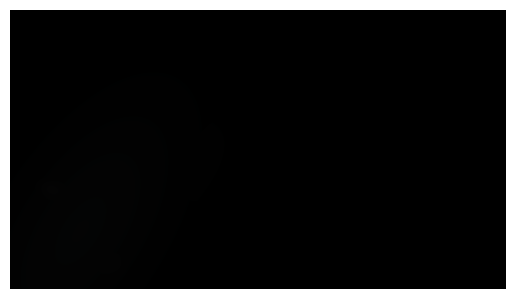

In [5]:
from pathlib import Path
ply_file = Path(r"C:\Users\Maemaeko\imari_lab\gaussian-splatting\output\6bd50db1-7\point_cloud\iteration_30000\point_cloud_v6.ply")
scene.gaussians.load_ply(ply_file)
gaussians = scene.gaussians
import matplotlib.pyplot as plt
view = scene.getTrainCameras()[36]
print(view.image_name)
print(view.FoVx, view.FoVy)
print(view.colmap_id)
bg_color = [1,1,1] if dataset.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
rendering = render(view, gaussians, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする



tensor([[ 0.,  1., -0.,  0.],
        [ 1.,  0., -0.,  0.],
        [ 0.,  0., -1.,  0.],
        [ 0.,  0.,  4.,  1.]], device='cuda:0')


(-0.5, 511.5, 511.5, -0.5)

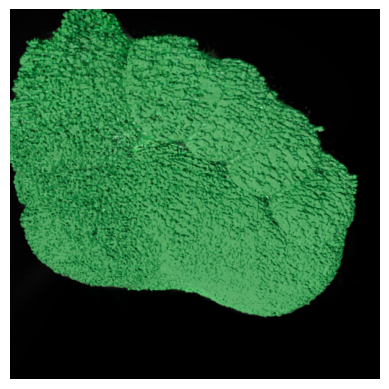

In [6]:
import numpy as np
R = np.array([[0, 1, 0], [1, 0, 0], [0, 0, -1]])
T = np.array([0, 0, 4])
from scene.cameras import Camera
from PIL import Image

view = Camera(
        colmap_id=87,
        R = R,
        T = T,
        FoVx=0.5565993180102227,
        FoVy=0.5565993180102227,
        image_name="none",
        uid=15,
        resolution=(512, 512),
        depth_params = None,
        image=Image.new('RGB', (512, 512), (0, 0, 0)),
        invdepthmap=None
    )
print(view.world_view_transform)

rendering = render(view, gaussians, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする



(-0.5, 1599.5, 899.5, -0.5)

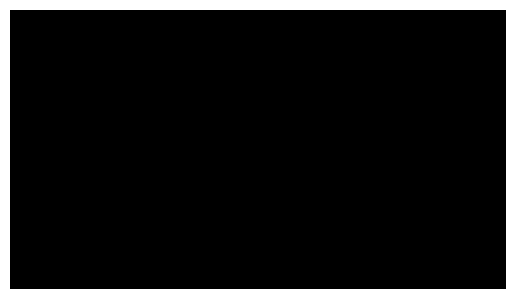

In [21]:
#import add_pypath
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'gaussian-splatting-lightning')))
import torch
import numpy as np
from internal.utils import gaussian_utils
import copy
from viser import transforms as vt
import math

xyz = gaussians.get_xyz
scaling = gaussians.get_scaling

rotation = gaussians.get_rotation

features_dc = gaussians.get_features_dc
features_rest = gaussians.get_features_rest

features = torch.cat([features_dc, features_rest], dim=-2)

class RotationUtils:
    @staticmethod
    def rx(theta):
        return np.matrix([[1, 0, 0],
                          [0, np.cos(theta), -np.sin(theta)],
                          [0, np.sin(theta), np.cos(theta)]])

    @staticmethod
    def ry(theta):
        return np.matrix([[np.cos(theta), 0, np.sin(theta)],
                          [0, 1, 0],
                          [-np.sin(theta), 0, np.cos(theta)]])

    @staticmethod
    def rz(theta):
        return np.matrix([[np.cos(theta), -np.sin(theta), 0],
                          [np.sin(theta), np.cos(theta), 0],
                          [0, 0, 1]])



# translate
#t_xyz = np.array([3.497, -0.494, 3.45])  # Translation vector
#t = np.array([1.359, -2.2241, 1.897], dtype=np.float32)  # Translation vector
t_xyz = np.array([1.359, -2.2241, 1.897], dtype=np.float32)  # Translation vector
xyz = gaussian_utils.GaussianTransformUtils.translation(xyz, *t_xyz.tolist())

# rotate
rx, ry, rz = math.radians(-88.58), math.radians(1.42), math.radians(93.38)
#rx, ry, rz = 0, 0, 0
rot_mat = RotationUtils.rx(rx) @ RotationUtils.ry(ry) @ RotationUtils.rz(rz)
r_wxyz = vt.SO3.from_matrix(rot_mat).wxyz

xyz, rotation, new_features = gaussian_utils.GaussianTransformUtils.rotate_by_wxyz_quaternions(
            xyz=xyz,
            rotations=rotation,
            features=features,
            quaternions=torch.tensor(r_wxyz).to(xyz),
        )

# rescale
xyz, scaling = gaussian_utils.GaussianTransformUtils.rescale(
            xyz,
            scaling,
            1.7
        )



gaussians_copy = copy.deepcopy(gaussians)
gaussians_copy._xyz = xyz
gaussians_copy._scaling = torch.log(scaling)

rendering = render(view, gaussians_copy, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする


In [10]:
# output gaussians
from pathlib import Path
output_path = Path(r"C:\Users\Maemaeko\imari_lab\gaussian-splatting\output\6bd50db1-7\point_cloud\iteration_30000\output_cloud.ply")
gaussians_copy.save_ply(output_path)

3_0181.png
[[-0.98992062  0.10534552  0.0946546 ]
 [-0.08064862  0.13008268 -0.98821774]
 [-0.11641723 -0.98589088 -0.12027555]]
[-0.28322088  2.4635013   3.19446734]
tensor([[ 0.1359, -0.1605,  0.9776,  0.0000],
        [-0.1442, -0.9795, -0.1407,  0.0000],
        [ 0.9802, -0.1218, -0.1563,  0.0000],
        [ 1.8760,  7.6158,  1.8634,  1.0000]], device='cuda:0')


(-0.5, 1599.5, 899.5, -0.5)

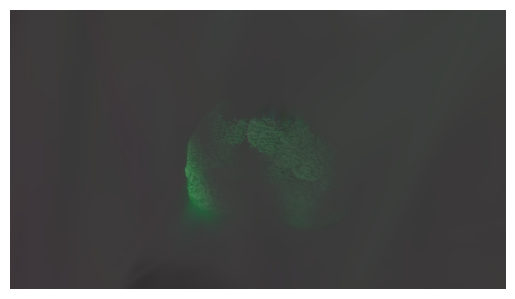

In [22]:
from scene.cameras import Camera
from PIL import Image

views = scene.getTrainCameras()
view = views[36]
print(view.image_name)
print(view.R)
print(view.T)
import numpy as np
w2c = np.eye(4, dtype=view.R.dtype)
w2c[:3, :3] = view.R
w2c[:3, 3] = view.T

import numpy as np, math

# 1) 平行移動
#t =  np.array([0, 0, 0]) 
t = np.array([1.359, -2.2241, 1.897], dtype=np.float32)  # Translation vector
T = np.eye(4, dtype=np.float32)
T[:3, 3] = t

# 2) 回転（既に rot_mat が 3x3 で得られている想定）
#    RotationUtils.rx/ry/rz が numpy array を返すならそのまま使えます
rx, ry, rz = math.radians(-88.58), math.radians(1.42), math.radians(93.38)
#rx, ry, rz = 0, 0, 0  # 例としてゼロ回転を使用
rot_mat = RotationUtils.rx(rx) @ RotationUtils.ry(ry) @ RotationUtils.rz(rz)
R3 = RotationUtils.rx(rx) @ RotationUtils.ry(ry) @ RotationUtils.rz(rz)
R = np.eye(4, dtype=np.float32)
R[:3, :3] = R3

# 3) スケール
s = 1.7
S = np.eye(4, dtype=np.float32)
S[0,0] = S[1,1] = S[2,2] = s

 

view = Camera(
        colmap_id=87,
        R = view.R,
        T = view.T,
        FoVx=0.704232208709321,
        FoVy=0.4076177113708152,
        image_name="none",
        uid=15,
        resolution=(1600, 900),
        depth_params = None,
        image=Image.new('RGB', (1600, 900), (0, 0, 0)),
        invdepthmap=None,
        trans=t,  # 平行移動
        scale=s,
        rotate= rot_mat
    )
print(view.world_view_transform)


rendering = render(view, gaussians_copy, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする

In [25]:
import numpy as np
from scene.cameras import Camera


def spherical_to_cartesian(theta, phi, radius):
    x  = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return np.array([x, y, z])

def look_at_transform(
        center,
        lookat,
        up,
    ):
    z = lookat - center

    z = z / np.linalg.norm(z)

    x = np.cross(up, z)
    if np.all(x == 0):
        x = np.cross(up, z + np.array([1e-6, 1e-6, 1e-6]))  # Avoid zero vector
    x = x / np.linalg.norm(x)

    y = np.cross(z, x)
    R = np.stack([x, y, z], axis=1)
    t = -R.T @ center
    view_matrix = np.eye(4)
    view_matrix[:3, :3] = R
    view_matrix[:3, 3] = t
    return view_matrix

def view_matrix_from_spherical(
        theta,
        phi,
        radius,
        lookat = np.array([0, 0, 0]),
        up = np.array([0, 0, 1])
    ):
    center = spherical_to_cartesian(theta, phi, radius)
    return look_at_transform(center, lookat, up)

def get_camera(theta, phi, radius, up=np.array([0, 0, 1])):
    theta = np.array(theta)
    phi = np.array(phi)
    w2c = view_matrix_from_spherical(theta, phi, radius, up=up)
    _r = w2c[:3, :3]
    _t = w2c[:3, 3]

    return Camera(
        colmap_id=65,
        R = _r,
        T = _t, 
        FoVx=0.7119294220716936,
        FoVy=0.4123349887767067,
        image_name="none",
        uid=15,
        resolution=(512, 512),
        depth_params = None,
        image=Image.new('RGB', (512, 512), (0, 0, 0)),
        invdepthmap=None
    )

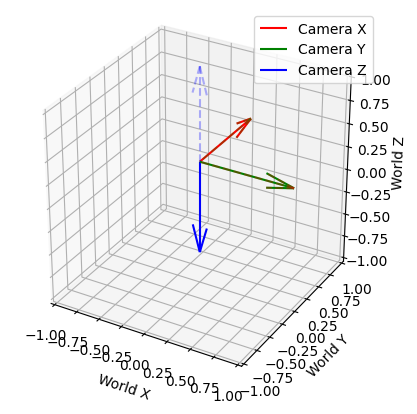

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# w2c の R
R_w2c = np.array([
    [-0.,  1.,  0.],
    [ 1.,  0.,  0.],
    [ 0.,  0., -1.]
])

# カメラ座標系の軸方向をワールド座標で求める (R_c2w = R_w2c.T)
R_c2w = R_w2c.T

# 原点（カメラ位置）から各軸の方向ベクトル（長さ1）
origin = np.array([0, 0, 0.3])  # カメラの位置
x_axis = R_c2w[:, 0]  # カメラX軸（赤）
y_axis = R_c2w[:, 1]  # カメラY軸（緑）
z_axis = R_c2w[:, 2]  # カメラZ軸（青）

# 描画
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# カメラ軸
ax.quiver(*origin, *x_axis, color='r', label='Camera X')
ax.quiver(*origin, *y_axis, color='g', label='Camera Y')
ax.quiver(*origin, *z_axis, color='b', label='Camera Z')

# ワールド軸（比較用）
ax.quiver(*origin, 1, 0, 0, color='r', alpha=0.3, linestyle='dashed')
ax.quiver(*origin, 0, 1, 0, color='g', alpha=0.3, linestyle='dashed')
ax.quiver(*origin, 0, 0, 1, color='b', alpha=0.3, linestyle='dashed')

# 軸範囲
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

ax.set_xlabel('World X')
ax.set_ylabel('World Y')
ax.set_zlabel('World Z')
ax.legend()
ax.set_box_aspect([1,1,1])
plt.show()


In [ ]:
view = get_camera(0, 0, 4, up=np.array([1, 0, 0]))

rendering = render(view, gaussians_copy, pipeline, background, use_trained_exp=dataset.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)["render"]

# レンダリングの可視化
rendering = rendering.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(rendering)
plt.axis('off')  # 軸を非表示にする
